# This notebook contains topic trends and visualization for every month using BERTopic
## Graphs are at the end of the notebook 


## Kindly upvote if you like my work and feel free to comment and suggest changes. It motivates me to do more work.

#### The results of this study show that NMF is best suited for finding topics in the corpus, while BERTopic is best suited for finding topic trends over time. Specifically, NMF was found to have the best performance in identifying clear and distinct topics, while BERTopic was found to be particularly effective in capturing the evolution of topics over time.



## Also checkout Notebooks for:-

### NMF(Non-Negative Matrix Factorization) - https://www.kaggle.com/code/divyapatel4/topic-modelling-and-visualization-using-nmf/
### LDA (Latent Dirichlet Allocation) - https://www.kaggle.com/code/divyapatel4/topic-modelling-and-visualization-using-lda/
### DTM (Dynamic Topic Model) - https://www.kaggle.com/code/divyapatel4/topic-trends-using-dtm-dynamic-topic-models/


## Pre-processing and cleaning of data is done in the following notebook which is used to make cord_df dataset used in this notebook.

### Data Pre-processing and Cleaning - https://www.kaggle.com/code/divyapatel4/cord-19-dataset-cleaner/




In [1]:
import numpy as np
import pandas as pd 
import glob
import json
import seaborn as sns
from tqdm import tqdm


import matplotlib.pyplot as plt
plt.style.use('ggplot')


from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string
import re
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import TweetTokenizer, RegexpTokenizer
import nltk
from nltk.stem import WordNetLemmatizer 
lemmatizer = WordNetLemmatizer()


from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from operator import itemgetter
import gensim
from gensim.utils import simple_preprocess
import numpy as np
from collections import Counter
import pprint 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import glob
import json
from tqdm import tqdm
import numpy as np
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from gensim.models.nmf import Nmf
from collections import Counter
from operator import itemgetter
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string
import re
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import TweetTokenizer, RegexpTokenizer
import nltk


In [2]:
df = pd.read_csv('/kaggle/input/cord-df/df_10000_processed.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9995 entries, 0 to 9994
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   paper_id          9995 non-null   object
 1   doi               9995 non-null   object
 2   abstract          7108 non-null   object
 3   body_text         9995 non-null   object
 4   authors           9941 non-null   object
 5   title             9995 non-null   object
 6   journal           9340 non-null   object
 7   abstract_summary  9995 non-null   object
 8   language          9995 non-null   object
 9   publish_time      9995 non-null   object
 10  word_count        9995 non-null   int64 
 11  processed_text    9995 non-null   object
dtypes: int64(1), object(11)
memory usage: 937.2+ KB


In [3]:
# Get the top 20 most common words among all the articles
temp_text = df['processed_text']

# split single string in format of "['word1', 'word2', 'word3', ...]" to list of string ['word1' , 'word2', 'word3', ...]
try:
    temp_text = temp_text.apply(lambda x: x[1:-1].split(', '))
    temp_text = temp_text.apply(lambda x: [item[1:-1] for item in x])
except:
    print("already in req. format")
p_text = [item for sublist in temp_text for item in sublist]

df['processed_text'] = temp_text


In [4]:
# remove sopwords and all non-alphabetic characters from processed_text column and save it in processed_text column

stopwords = ['cc','by','international','nd','nc','doi','org','no','https','january','february', 'march','april','may','june','july','august', 'september','october','november','december','`','\'','covid','sars','cov']

stopwords = set(stopwords)
# print frequency of cc in processed_text column
print("Frequency of cc in processed_text column: ", df['processed_text'].apply(lambda x: x.count('cc')).sum())

# Remove stopwords from processed_text column
df['processed_text'] = df['processed_text'].apply(lambda x: [item for item in x if item not in stopwords])

# print frequency of cc in processed_text column
print("Frequency of cc in processed_text column: ", df['processed_text'].apply(lambda x: x.count('cc')).sum())

# print frequency of sars 
print("Frequency of sars in processed_text column: ", df['processed_text'].apply(lambda x: x.count('sars')).sum())

Frequency of cc in processed_text column:  1167
Frequency of cc in processed_text column:  0
Frequency of sars in processed_text column:  0


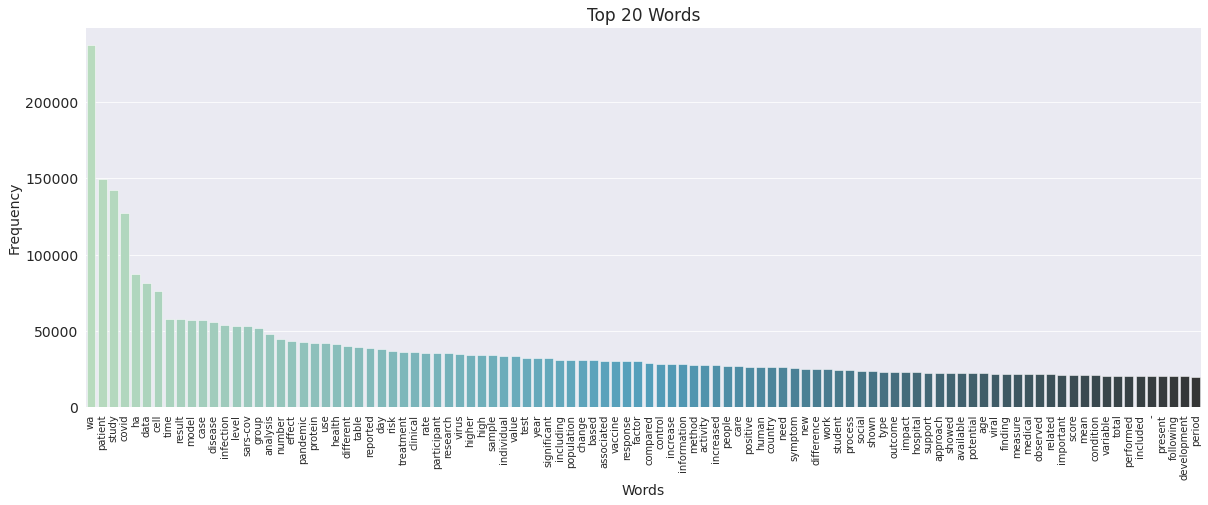

In [5]:

# Top 20
top_20 = pd.DataFrame(
    Counter(p_text).most_common(100),
    columns=['word', 'frequency']
)

# Plot a bar chart for the top 20 most frequently occuring words
fig = plt.figure(figsize=(20,7))

g = sns.barplot(
    x='word',
    y='frequency',
    data=top_20,
    palette='GnBu_d'
)

g.set_xticklabels(
    g.get_xticklabels(),
    rotation=90,
    fontsize=10
)

plt.yticks(fontsize=14)
plt.xlabel('Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Top 20 Words', fontsize=17)

plt.show()


## Number of Unique Words...

In [6]:
# Get the number of unique words after processing
num_unique_words = len(set(p_text))
num_unique_words

324401

In [7]:
# retain df after may 2020 to may 2022

df['publish_time'] = pd.to_datetime(df['publish_time'])
df = df[df['publish_time'] >= '2020-05-01']
df = df[df['publish_time'] < '2022-06-01']


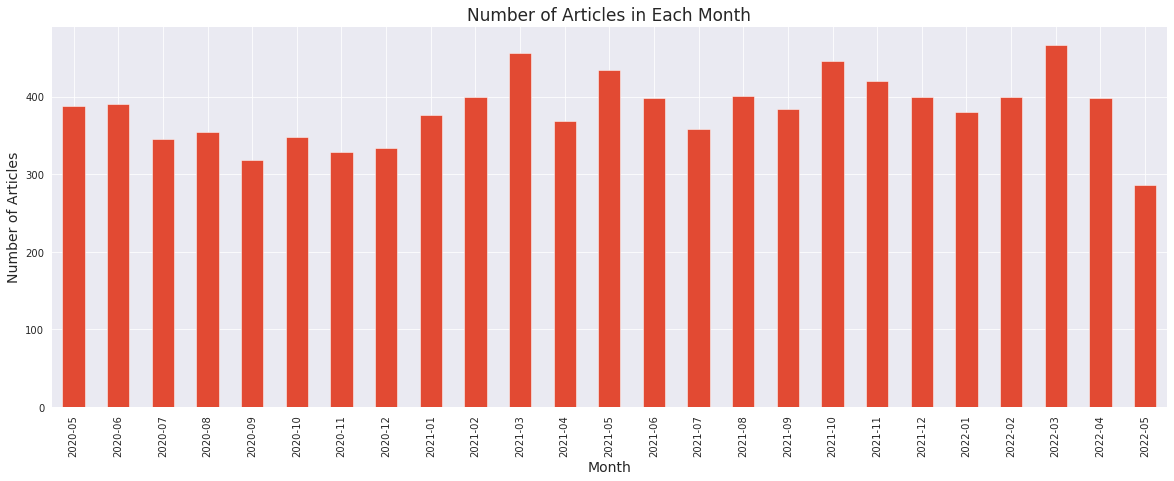

In [8]:
# plot graph for number of articles in each month from november 2019 to december 2022 in bins of 1 month

df_copy = df.copy()
df_copy['publish_time'] = pd.to_datetime(df_copy['publish_time'])
df_copy['publish_time'] = df_copy['publish_time'].dt.to_period('M')
articles_per_month = df_copy['publish_time'].value_counts().sort_index()
df_copy['publish_time'].value_counts().sort_index().plot(kind='bar', figsize=(20,7))
plt.title('Number of Articles in Each Month', fontsize=17)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Articles', fontsize=14)
plt.show()

del df_copy

In [9]:
df = df.sort_values(by='publish_time')

df.head(100)


,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,language,publish_time,word_count,processed_text
4499,b23f0b5c3816d199965b77d07975c794313c45f4,10.1097/mat.0000000000001174,The COVID-19 pandemic has resulted in challeng...,The COVID-19 pandemic has resulted in challeng...,"Slaughter, Mark S.",COVID-19 Update,ASAIO J,The COVID-19 pandemic has resulted in<br>chal...,en,2020-05-01,474,"[pandemic, ha, resulted, challenge, rarely, se..."
1771,081efe4125bc65abe3c5cedf579e8de10a1036aa,10.3349/ymj.2020.61.5.431,NaN,Patient electronic medical records were review...,"Hong, Kyung Soo. Lee, Kwan Ho. Chung, Jin H...",Clinical Features and Outcomes of 98 Patients...,Yonsei Med J,Not provided.,en,2020-05-01,1562,"[patient, electronic, medical, record, clinica..."
8068,8665c472447de7ef27c2d3e3ecc36d22304fcf93,10.1101/2020.04.26.20079418,Ten days after the first reported case of SARS...,Although direct transmission in the hospitals ...,"Sikkema, R. S.. Pas, S.. Nieuwenhuijse, D. ...",COVID-19 in healthcare workers in three<br>ho...,NaN,Ten days after the first reported case of<br>...,en,2020-05-01,2344,"[direct, transmission, hospital, ruled, data, ..."
3109,ef4524fef38d9807bf18d9e73cbd44f1814fbc23,10.1111/jgs.16499,NaN,"policy proposals are being hastily adopted, so...","Gurwitz, Jerry H.","COVID‐19, Post‐acute Care Preparedness and<br...",J Am Geriatr Soc,Not provided.,en,2020-05-01,869,"[policy, proposal, hastily, adopted, risk, uni..."
5566,d35c494cf9ac2d7988bcd71c9c9fb1df4bea27ce,10.1016/j.jacr.2020.04.027,NaN,There is no such thing as a coronavirus diseas...,"Georgiades, Christos",Leadership Lessons From Prior Pandemics:<br>T...,J Am Coll Radiol,Not provided.,en,2020-05-01,1043,"[thing, coronavirus, disease, crisis, virus, p..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1628,b57ebafea27b01bad7138b7213509ea9145d689f,10.1101/2020.04.28.066761,The dependence of the host on the interaction ...,"Heparin, the second most widely used drug by w...","Mycroft-West, Courtney J.. Su, Dunhao. <br>P...",Heparin inhibits cellular invasion by<br>SARS...,bioRxiv,The dependence of the host on the interaction...,en,2020-05-08,5747,"[heparin, second, widely, drug, weight, global..."
3429,4aac338565fbaf6a69ca06d73972a63ea1119313,10.1155/2020/1372494,Type I interferons (IFN-I) are a group of rela...,Type I interferons (IFN-I) are members from a ...,"Acosta, Patricio L.. Byrne, Alana B.. Hijan...",Human Type I Interferon Antiviral Effects in<...,J Immunol Res,Type I interferons (IFN-I) are a group of<br>...,en,2020-05-08,9996,"[type, interferon, ifn-i, member, large, famil..."
5472,e8ad5180fc8bf15ea168c8d7d03b5707afe5efb3,10.1016/j.jcv.2020.104412,The final months of 2019 witnessed the emergen...,"2 available, i.e. real-time reverse transcript...","van Kasteren, Puck B.. van der Veer, Bas. v...",Comparison of commercial RT-PCR diagnostic<br...,J Clin Virol,The final months of 2019 witnessed the<br>eme...,en,2020-05-08,1365,"[available, real-time, reverse, transcriptase,..."
8681,8a784c9ee4dd3205a0a3106e4480d0ca0ef6b8c5,10.1101/2020.05.05.20092023,"This study anonymously screened 13,332 individ...",4 manifestations as its effects on the nervous...,"Plomecka, M. B.. Gobbi, S.. Neckels, R.. <b...",Mental Health Impact of COVID-19: A global<br...,NaN,"This study anonymously screened 13,332<br>ind...",en,2020-05-09,5144,"[manifestation, effect, nervous, increasingly,..."


In [10]:
articles_per_month = list(articles_per_month)
print(articles_per_month)

[388, 391, 345, 354, 318, 348, 328, 334, 376, 400, 456, 368, 434, 398, 358, 401, 384, 446, 420, 399, 380, 400, 467, 398, 286]


# Applying BERTopic

In [11]:

df['month'] = df['publish_time'].dt.month
df['year'] = df['publish_time'].dt.year

In [12]:
df.head()

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,language,publish_time,word_count,processed_text,month,year
4499,b23f0b5c3816d199965b77d07975c794313c45f4,10.1097/mat.0000000000001174,The COVID-19 pandemic has resulted in challeng...,The COVID-19 pandemic has resulted in challeng...,"Slaughter, Mark S.",COVID-19 Update,ASAIO J,The COVID-19 pandemic has resulted in<br>chal...,en,2020-05-01,474,"[pandemic, ha, resulted, challenge, rarely, se...",5,2020
1771,081efe4125bc65abe3c5cedf579e8de10a1036aa,10.3349/ymj.2020.61.5.431,NaN,Patient electronic medical records were review...,"Hong, Kyung Soo. Lee, Kwan Ho. Chung, Jin H...",Clinical Features and Outcomes of 98 Patients...,Yonsei Med J,Not provided.,en,2020-05-01,1562,"[patient, electronic, medical, record, clinica...",5,2020
8068,8665c472447de7ef27c2d3e3ecc36d22304fcf93,10.1101/2020.04.26.20079418,Ten days after the first reported case of SARS...,Although direct transmission in the hospitals ...,"Sikkema, R. S.. Pas, S.. Nieuwenhuijse, D. ...",COVID-19 in healthcare workers in three<br>ho...,NaN,Ten days after the first reported case of<br>...,en,2020-05-01,2344,"[direct, transmission, hospital, ruled, data, ...",5,2020
3109,ef4524fef38d9807bf18d9e73cbd44f1814fbc23,10.1111/jgs.16499,NaN,"policy proposals are being hastily adopted, so...","Gurwitz, Jerry H.","COVID‐19, Post‐acute Care Preparedness and<br...",J Am Geriatr Soc,Not provided.,en,2020-05-01,869,"[policy, proposal, hastily, adopted, risk, uni...",5,2020
5566,d35c494cf9ac2d7988bcd71c9c9fb1df4bea27ce,10.1016/j.jacr.2020.04.027,NaN,There is no such thing as a coronavirus diseas...,"Georgiades, Christos",Leadership Lessons From Prior Pandemics:<br>T...,J Am Coll Radiol,Not provided.,en,2020-05-01,1043,"[thing, coronavirus, disease, crisis, virus, p...",5,2020


### Free memory

In [13]:
# drop useless columns like body_text, abstract, abstract_summary 
df = df.drop(['body_text'], axis=1)
df = df.drop(['abstract_summary'], axis=1)


In [14]:
df.head()

,paper_id,doi,abstract,authors,title,journal,language,publish_time,word_count,processed_text,month,year
4499,b23f0b5c3816d199965b77d07975c794313c45f4,10.1097/mat.0000000000001174,The COVID-19 pandemic has resulted in challeng...,"Slaughter, Mark S.",COVID-19 Update,ASAIO J,en,2020-05-01,474,"[pandemic, ha, resulted, challenge, rarely, se...",5,2020
1771,081efe4125bc65abe3c5cedf579e8de10a1036aa,10.3349/ymj.2020.61.5.431,NaN,"Hong, Kyung Soo. Lee, Kwan Ho. Chung, Jin H...",Clinical Features and Outcomes of 98 Patients...,Yonsei Med J,en,2020-05-01,1562,"[patient, electronic, medical, record, clinica...",5,2020
8068,8665c472447de7ef27c2d3e3ecc36d22304fcf93,10.1101/2020.04.26.20079418,Ten days after the first reported case of SARS...,"Sikkema, R. S.. Pas, S.. Nieuwenhuijse, D. ...",COVID-19 in healthcare workers in three<br>ho...,NaN,en,2020-05-01,2344,"[direct, transmission, hospital, ruled, data, ...",5,2020
3109,ef4524fef38d9807bf18d9e73cbd44f1814fbc23,10.1111/jgs.16499,NaN,"Gurwitz, Jerry H.","COVID‐19, Post‐acute Care Preparedness and<br...",J Am Geriatr Soc,en,2020-05-01,869,"[policy, proposal, hastily, adopted, risk, uni...",5,2020
5566,d35c494cf9ac2d7988bcd71c9c9fb1df4bea27ce,10.1016/j.jacr.2020.04.027,NaN,"Georgiades, Christos",Leadership Lessons From Prior Pandemics:<br>T...,J Am Coll Radiol,en,2020-05-01,1043,"[thing, coronavirus, disease, crisis, virus, p...",5,2020


In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
!pip install bertopic
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu116
!pip install bertopic
!pip install cuml-cu11 --extra-index-url=https://pypi.ngc.nvidia.com

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.9/103.9 kB 705.3 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 2.1 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 12.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 636.6/636.6 kB 43.1 MB/s eta 0:00:00
  Created wheel for hdbscan: filename=hdbscan-0.8.29-cp37-cp37m-linux_x86_64.whl size=3426746 sha256=532fc26da6186cede17b3f8c760f47f483b077a48ac2049f523618812e96dc73
  Stored in directory: /root/.cache/pip/wheels/93/78/2e/03ee191669a772e9653260aa3bd53e0b1a768751a9676e8c82
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125938 sha256=05c209d5a8553bc0155b23e46362ef178bb5cc5ec582e5c77af38b2a1b5fdca4
  Stored in directory

In [17]:
df['processed_text'] = df['processed_text'].apply(lambda x: ' '.join(x))


In [18]:
df['processed_text']

4499    pandemic ha resulted challenge rarely seen hea...
1771    patient electronic medical record clinical dat...
8068    direct transmission hospital ruled data doe su...
3109    policy proposal hastily adopted risk unintende...
5566    thing coronavirus disease crisis virus precise...
                              ...                        
5076    example keeping dream diary increase dream rec...
5444    infectious disease epidemiology ha recently su...
1987    united_state food drug administration fda auth...
3307    receive device implant population largely unde...
4919    new disease wa reported named zhou soon virus ...
Name: processed_text, Length: 9577, dtype: object

In [19]:
df = df.reset_index(drop=True)


In [20]:
from bertopic import BERTopic
text_ = df['processed_text']

topic_model = BERTopic( min_topic_size= 50 , nr_topics= 20 , verbose=True, n_gram_range = (1,2) )
topics, probabilities = topic_model.fit_transform(text_)



Downloading:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/190 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/612 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

Downloading:   0%|          | 0.00/349 [00:00<?, ?B/s]

Batches:   0%|          | 0/300 [00:00<?, ?it/s]

2023-02-11 05:36:51,082 - BERTopic - Transformed documents to Embeddings


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


2023-02-11 05:37:24,190 - BERTopic - Reduced dimensionality
2023-02-11 05:37:24,675 - BERTopic - Clustered reduced embeddings
2023-02-11 05:41:33,734 - BERTopic - Reduced number of topics from 31 to 21


In [21]:

freq = topic_model.get_topic_info()
freq.head(20)

,Topic,Count,Name
0,-1,5055,-1_wa_patient_study_ha
1,0,583,0_protein_sarscov_cell_virus
2,1,453,1_vaccine_vaccination_wa_antibody
3,2,393,2_study_wa_child_mentalhealth
4,3,324,3_cell_il_wa_patient
5,4,293,4_energy_ha_country_wa
6,5,288,5_student_learning_teacher_education
7,6,236,6_cancer_patient_wa_cell
8,7,223,7_patient_nurse_care_nursing
9,8,198,8_wa_cell_drug_compound


In [22]:
topic_nr = freq.iloc[0]['Topic']
topic_model.get_topic(topic_nr)

[('wa', 0.01369525113746963),
 ('patient', 0.011366232536672195),
 ('study', 0.010513779997745906),
 ('ha', 0.006987761194540562),
 ('data', 0.00691225142432233),
 ('disease', 0.005895543405722847),
 ('case', 0.005771067840623377),
 ('cell', 0.005642112000807724),
 ('level', 0.005297073664105877),
 ('time', 0.005171790324602256)]

In [23]:
fig = topic_model.visualize_topics()
fig


In [24]:
topic_over_time = topic_model.topics_over_time(docs = text_, timestamps = df['publish_time'], nr_bins = 25, global_tuning = True,evolution_tuning = True)

25it [3:17:48, 474.72s/it]


In [25]:
topic_model.visualize_topics_over_time(topic_over_time, top_n_topics = 20)



In [26]:
topic_model.visualize_heatmap()


In [27]:
topic_model.visualize_barchart(top_n_topics=20, n_words=5, height=800)


In [28]:
topic_model.get_representative_docs(
    topic_model.find_topics('recommender system')[0][0])


["age mass surveillance censorship user rely anonymization technique exercise right freedom expression freely access information currently tor popular low-latency anonymization network designed hide user identity ip address service provider prevent party exposing relationship communicating partner internet accomplish goal user traffic sent tor encrypted multiple layer forwarded tor node known entry middle exit popularity attractive target adversary aiming compromise tor user applying traffic analysis adversary simultaneously observes user traffic entering exiting tor perform traffic correlation packet size timing deanonymize user connection website fingerprinting wfp type traffic analysis adversary aim identify website visited tor user observing pattern data flow user entry node common example entity position execute type attack autonomous called network-level adversary lie path tor user destination recent study shown natural internet routing dynamic active attack border gateway protoc

In [29]:
topic_model._sort_mappings_by_frequency


<bound method BERTopic._sort_mappings_by_frequency of <bertopic._bertopic.BERTopic object at 0x7f237b707f90>>

In [30]:
topic_model.get_params()


{'calculate_probabilities': False,
 'ctfidf_model': ClassTfidfTransformer(),
 'diversity': None,
 'embedding_model': <bertopic.backend._sentencetransformers.SentenceTransformerBackend at 0x7f2342809350>,
 'hdbscan_model': HDBSCAN(min_cluster_size=50, prediction_data=True),
 'language': 'english',
 'low_memory': False,
 'min_topic_size': 50,
 'n_gram_range': (1, 2),
 'nr_topics': 20,
 'seed_topic_list': None,
 'top_n_words': 10,
 'umap_model': UMAP(angular_rp_forest=True, low_memory=False, metric='cosine', min_dist=0.0, n_components=5, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True}),
 'vectorizer_model': CountVectorizer(ngram_range=(1, 2)),
 'verbose': True}

In [ ]:
import seaborn as sns

fig = plt.figure(figsize=(20,10))
ax = sns.swarmplot(data = df, x = 'Topic', y = 'publish_time', hue = 'Topic', palette = 'Set2', size = 5)

